Una vez finalizada la fase de limpieza de datos, en la que se han tratado los valores nulos, eliminado los registros duplicados, verificado la consistencia de los datos y analizado los valores atípicos, el siguiente paso en el proceso de preparación del dataset es la fase de transformación.
Esta fase tiene como objetivo adaptar los datos a un formato adecuado para su posterior análisis exploratorio. Para ello, se llevarán a cabo una serie de transformaciones sobre las variables del datase.

En primer lugar, vamos a importar todas las librería necesarias para poder trabajar:

In [2]:
#Importamos pandas
import pandas as pd 
#Importamos numpy
import numpy as np 
#Importamos datetime
import datetime as dt 

#Importación de visualizaciones
import seaborn as sns
import matplotlib.pyplot as plt

#Importamos nuestro archivo de soporte
import sys
sys.path.append('../')
from Jupyters.soporte_def import *

print ("Librerias importadas")

Librerias importadas


En segundo lugar, vamos a importar el dataset que hemos obtenido tras la limpieza:

In [3]:
#En primer lugar importamos el dataset
df_original = pd.read_csv ("../Clean_Data/Dataframe_limpio.csv")
print ("Dataset importado")

Dataset importado


Hechas las primera tareas comunes a todos los scripts. Antes de realizar la transformación, vamos a definir el objetivo del estudio.

***Objetivo del EDA***

El objetivo que tiene este análisis exploratorio de datos y su posterior visualización es el de estudiar y comprender la longevidad de los jugadores de la NBA y como las diferentes variables afectan a esta.

Para poder llevar a cabo el estudio vamos a revisar las columnas dentro del dataset y a definir cuáles impactan en nuestro estudio. Una vez definidas, porcederemos a la transformación de los datos:

In [4]:
#Extraemos las columnas que conforman nuestro dataset actual
df_original.columns

Index(['id', 'general_team', 'general_city', 'general_team_name',
       'general_team_abbv', 'full_name', 'is_active', 'draft_team',
       'draft_city', 'draft_team_name', 'draft_team_abbrv',
       'organization_type', 'birthdate', 'country', 'weight', 'seniority',
       'position', 'from_year', 'to_year', 'g-league', 'nba', 'draft_year',
       'draft_round', 'draft_number', 'greatest_75_flag', 'jersey_def',
       'organization_def', 'height_definitivo'],
      dtype='str')

Las columnas que impactan con el objetivo de este estudio son las siguientes: 
- ID: Como identificador único del jugador
- General_team: Como identificador único del equipo en el que juega/ha jugado el jugador.
- General_city: Como ciudad en la que jueg/ha jugado el jugador. 
- General_team_name: Como nombre del equipo en el que juega/ha jugado el jugador.
- Full_name: Nombre del jugador
- Is_active: Nos informa de si el jugador está en activo. 
- Draft_team: Como identificador único del equipo drafteó al jugador.
- Draft_city: Como ciudad en la que el jugador fue drafteado. 
- Draft_team_name: Como nombre del equipo en el que el jugador fue drafteado. 
- Organization_type: Tipo de organización de la que provenía el jugador. 
- Country: País del que proviene el jugador.
- Weight: Peso del jugador
- Seniority: Temporadas que el jugador ha disputado en la liga 
- Position: Posición en la que juega/jugaba el jugador. 
- From_year: Temporada en la que empezó a jugar el jugador 
- To_year: Temporada en la que se retiró el jugador
- G-league: Indicador de si el jugador jugó en la liga de desarrollo de la NBA. 
- NBA: Identificador de si el jugador jugó en la NBA.
- Greatest_75_flag: Identificador de si el jugador está entre los mejores 75 de la historia. 
- Height_definitivo: Altura del jugador. 

In [5]:
#Creamos un nuevo dataset solo con las columnas seleccionadas.
df_work = df_original[['id', 'general_team', 'general_city', 'general_team_name', 'full_name', 'is_active', 'draft_team', 'draft_city', 
                       'draft_team_name', 'organization_type', 'country', 'weight', 'seniority', 'position', 'from_year', 'to_year',
                       'g-league', 'nba', 'greatest_75_flag', 'height_definitivo']].copy()

("Dataset copiado")

'Dataset copiado'

In [6]:
#Comprobamos las columnas del dataset
df_work.columns

Index(['id', 'general_team', 'general_city', 'general_team_name', 'full_name',
       'is_active', 'draft_team', 'draft_city', 'draft_team_name',
       'organization_type', 'country', 'weight', 'seniority', 'position',
       'from_year', 'to_year', 'g-league', 'nba', 'greatest_75_flag',
       'height_definitivo'],
      dtype='str')

In [7]:
#Comprobamos ahora los tipos de columna 
df_work.dtypes

id                     int64
general_team           int64
general_city             str
general_team_name        str
full_name                str
is_active            float64
draft_team           float64
draft_city               str
draft_team_name          str
organization_type        str
country                  str
weight               float64
seniority            float64
position                 str
from_year            float64
to_year              float64
g-league                 str
nba                      str
greatest_75_flag         str
height_definitivo    float64
dtype: object

**Paso 1 --> Exploración inicial de datos**

Como primer paso de la transformación, vamos a lanzar un EDA inicial para ver los datos con una función predefinida:

In [8]:
eda_inicial(df_work)

Variables numéricas: 
 Index(['id', 'general_team', 'is_active', 'draft_team', 'weight', 'seniority',
       'from_year', 'to_year', 'height_definitivo'],
      dtype='str')
 
                    count          mean           std           min  \
id                 3712.0  5.333399e+05  6.879675e+05  1.500000e+01   
general_team       3712.0  1.610613e+09  2.914681e+02  1.610613e+09   
is_active          3712.0  2.753000e-01  4.467000e-01  0.000000e+00   
draft_team         3712.0  1.230522e+09  6.839854e+08  0.000000e+00   
weight             3712.0  2.209200e+02  2.715500e+01  1.330000e+02   
seniority          3712.0  8.452600e+00  4.950900e+00  0.000000e+00   
from_year          3712.0  2.008573e+03  8.114300e+00  1.978000e+03   
to_year            3712.0  2.016116e+03  6.346200e+00  1.996000e+03   
height_definitivo  3712.0  2.000483e+02  9.073200e+00  1.651000e+02   

                            25%           50%           75%           max  
id                 2.550000e+03  2.01

**Paso 2 --> Revisión de columnas numéricas**

Habiendo obtenido estos primeros insights con nuestra función predefinida, vamos a empezar la transformación analizando las variables numéricas:

- Columna id

La columna id informa de los indentificadores únicos de los jugadores, esta columna no requiere de transformaciones ya que se utilizará unicamente como identificador si fuera necesario.

- Columna general_team

La columna general_team contiene los identificadores únicos de los equipos en los que juegan los jugadores. Como en el caso anterior, esta columna no requiere de transformaciones ya que se utilizará como identificador si fuera necesario.

- Columna is_active

Lo primero que observamos en esta columna que ya vimos en la fase de limpieza es que esta columna está guardada como una columna numérica cuando es categórica por lo que ya sabemos que requerirá de cambios. 

In [9]:
#Vamos a revisar los valores que tiene la columna informados.
df_work['is_active'].unique()

array([0., 1.])

In [10]:
#Visualizamos ahora algún registro de un jugador con cada valor para ver si está activo o no y entender cada número.
print(df_work[df_work['is_active'] == 1][['full_name', 'general_team_name']])

                full_name general_team_name
232          LeBron James         Cavaliers
478            Chris Paul           Hornets
650            Kyle Lowry         Grizzlies
657           P.J. Tucker           Raptors
737         Udonis Haslem              Heat
...                   ...               ...
3707           Trey Burke           Thunder
3708  Willie Cauley-Stein           Rockets
3709         RaiQuan Gray              Nets
3710      Zion Williamson            LeBron
3711        Stephen Curry            LeBron

[1022 rows x 2 columns]


Como podemos observar, los jugadores que tienen un 1 informado es que están activos en la liga a fecha de 2022 por lo que vamos a cambiar esos valores con la función map:

In [11]:
#Obtenemos los valores por categoría antes de la ejecución
print(df_work['is_active'].value_counts())

#Aplicamos la función map
df_work['is_active'] = df_work['is_active'].map({1: 'Active', 0 : 'Inactive'})

#Obtenemos los valores por categoría después de la ejecución
print(df_work['is_active'].value_counts())


is_active
0.0    2690
1.0    1022
Name: count, dtype: int64
is_active
Inactive    2690
Active      1022
Name: count, dtype: int64


In [12]:
#Por último revisamos que no queden nulos para ver que todo esté correctamente
df_work['is_active'].isna().sum().round(2)

np.int64(0)

In [13]:
#Por último revisamos el tipo de columna para ver que ha cambiado correctamente
print(df_work['is_active'].dtype)

str


- Columna draft_team

La columna draft_team contiene los identificadores únicos de los equipos en los que draftearon a los jugadores. Como en el caso anterior, esta columna no requiere de transformaciones ya que se utilizará como identificador si fuera necesario.

- Columna weight

La columna weight incluye el peso de los jugadores de la NBA. Como vimos durante la fase de limpieza, esta columna informa del peso en libras pero vamos a adaptarlo a un formato europeo y cambiarlo a kilogramos. Teniendo en cuenta que una libra son 0,453592 kg realizamos la siguiente conversión:

In [14]:
df_work['weight_kg'] = round (df_work['weight'] * 0.453592, 1) 
print (df_work['weight_kg'])

0       100.2
1       111.1
2       116.6
3       131.5
4       108.9
        ...  
3707     83.9
3708    108.9
3709    122.0
3710    128.8
3711     83.9
Name: weight_kg, Length: 3712, dtype: float64


Una vez hemos realizado el cambio y hemos visto que se ha realizado correctamente procedemos a eliminar la columna anterior. Además, cambiaremos el nombre de la columna nueva a weight.

In [15]:
#Eliminamos la columna
df_work = df_work.drop(columns= ['weight'])
print ("Columna eliminada")

Columna eliminada


In [16]:
#Renombramos la columna 
df_work.rename(columns={'weight_kg': 'weight'}, inplace=True)
df_work['weight']

0       100.2
1       111.1
2       116.6
3       131.5
4       108.9
        ...  
3707     83.9
3708    108.9
3709    122.0
3710    128.8
3711     83.9
Name: weight, Length: 3712, dtype: float64

Una vez hemos realizado el cambio comprobamos que no queden nulos adicionales.

In [17]:
df_work['weight'].isna().sum()

np.int64(0)

- Columna seniority

Esta columna informa de la experiencia de los jugadores en la liga, vamos a revisar que no queden nulos dentro de la columna. Esta columna tras confirmar que no queden nulos no requerirá cambios adicionales.

In [18]:
df_work['seniority'].isna().sum()

np.int64(0)

- Columna from_year:

Esta columna informa del año en el que el jugador inició su carrera. Como en el caso anterior vamos a revisar que no tenga nulos y consideramos que no requerirá de cambios adicionales.

In [19]:
df_work['from_year'].isna().sum()

np.int64(0)

- Columna to_year:

Esta columna informa del año en el que el jugador dejó de jugar. Como en el caso anterior vamos a revisar que no tengan nulos y consideramos que no requerirá cambios adicionales.

In [20]:
df_work['to_year'].isna().sum()

np.int64(0)

- Columna height_definitivo

Esta columna informa de la altura del jugador. Como en los anteriores casos, revisaremos los nulos para verificar que no hay y no requerirá de modificaciones adicionales.

In [21]:
df_work['height_definitivo'].isna().sum()

np.int64(0)

**Paso 3 --> Revisión de columnas categóricas**

Una vez revisadas las columnas numéricas pasamos a la revisión de columnas categóricas. Para ello vamos a volver a hacer la extracción del eda inicial tras el cambio de la columna is_active:

In [22]:
eda_inicial(df_work)

Variables numéricas: 
 Index(['id', 'general_team', 'draft_team', 'seniority', 'from_year', 'to_year',
       'height_definitivo', 'weight'],
      dtype='str')
 
                    count          mean           std           min  \
id                 3712.0  5.333399e+05  6.879675e+05  1.500000e+01   
general_team       3712.0  1.610613e+09  2.914681e+02  1.610613e+09   
draft_team         3712.0  1.230522e+09  6.839854e+08  0.000000e+00   
seniority          3712.0  8.452600e+00  4.950900e+00  0.000000e+00   
from_year          3712.0  2.008573e+03  8.114300e+00  1.978000e+03   
to_year            3712.0  2.016116e+03  6.346200e+00  1.996000e+03   
height_definitivo  3712.0  2.000483e+02  9.073200e+00  1.651000e+02   
weight             3712.0  1.002114e+02  1.231700e+01  6.030000e+01   

                            25%           50%           75%           max  
id                 2.550000e+03  2.019540e+05  1.626204e+06  1.631323e+06  
general_team       1.610613e+09  1.610613e+09

Una vez extraído el eda inicial, vamos a proceder a revisar las columnas categóricas con una función predefinida:

- Columna general_city:

Esta columna nos muestra la ciudad en la que juega el jugador. Vamos a realizar el análisis inicial para ver si requiere de cambios adicionales:

VARIABLE: general_city
 
Número de categorías: 37
 
Distribución de frecuencias
general_city
Los Angeles                  184
Houston                      156
Cleveland                    145
New York                     142
Dallas                       137
Milwaukee                    134
Philadelphia                 133
Atlanta                      130
Boston                       130
Sacramento                   128
Detroit                      125
Washington                   124
Chicago                      123
Toronto                      120
Miami                        118
Golden State                 116
Memphis                      116
San Antonio                  115
Charlotte                    114
Minnesota                    113
New Orleans                  113
Phoenix                      111
Indiana                      108
Utah                         107
Oklahoma City                104
Portland                     101
Orlando                       98
Denver          

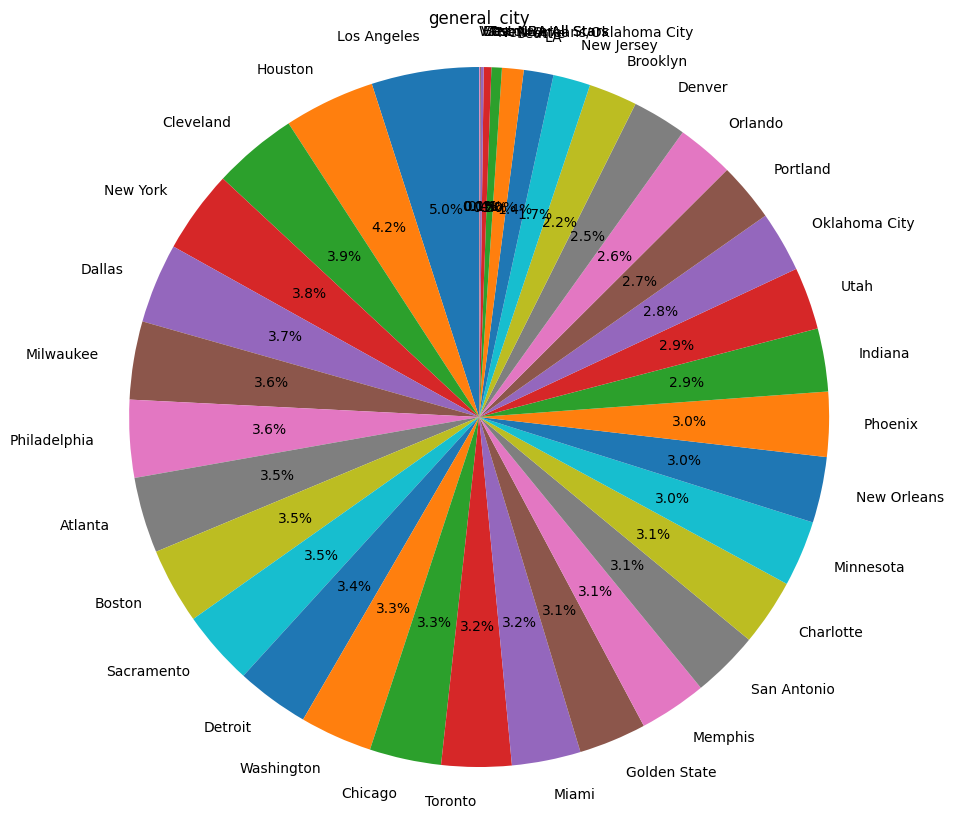

In [23]:
cat_analysis(df_work[['general_city']])

En esta columna, hay una serie de transformaciones que tenemos que realizar:
1. New Orleans/Oklahoma: Esta categoría consta de 18 jugadores que formaban parte del equipo que se mudó de New orleans a Oklahoma ya que incluirlos en el equipo erróneo vamso a eliminar dichos registros.

2. Team: Esta categoría consta de 13 jugadores, esta la vamos a eliminar ya que no podemos identificar con que equipo juega.

3. East NBA All Stars + West NBA All Stars: Combinadas tienen 6 registros que vamos a eliminar por que no aportan información suficientemente relevante como para identificar a todos los jugadores All Star. 

4. LA: Hay 51 filas con el registro de LA dichas filas con registro de LA las cambiaremos de ciudad LA a Los Angeles.

In [24]:
#1. Obtenemos la forma del DF antes de eliminar los datos
print(f'Filas antes de eliminar los registros: {len(df_work)}')

#2. Eliminamos las columnas 
df_work = df_work[df_work['general_city'] != 'New Orleans/Oklahoma City'].reset_index(drop=True)
df_work = df_work[df_work['general_city'] != 'Team'].reset_index(drop=True)
df_work = df_work[df_work['general_city'] != 'East NBA All Stars'].reset_index(drop=True)
df_work = df_work[df_work['general_city'] != 'West NBA All Stars'].reset_index(drop=True)

# Verificamos el resultado
print(f"Filas tras eliminar registros: {len(df_work)}")

Filas antes de eliminar los registros: 3712
Filas tras eliminar registros: 3675


Una vez eliminados esos registros, ahora convertimos los registros de LA a Los Angeles utilizando la función replace: 

In [25]:
df_work['general_city'] = df_work['general_city'].replace('LA', 'Los Angeles')
print ("Valores ajustados")

Valores ajustados


Para comprobar que todos los cambios se han hecho bien, extraemos ahora los valores únicos de la columna:

In [26]:
df_work['general_city'].value_counts()

general_city
Los Angeles      235
Houston          156
Cleveland        145
New York         142
Dallas           137
Milwaukee        134
Philadelphia     133
Atlanta          130
Boston           130
Sacramento       128
Detroit          125
Washington       124
Chicago          123
Toronto          120
Miami            118
Golden State     116
Memphis          116
San Antonio      115
Charlotte        114
Minnesota        113
New Orleans      113
Phoenix          111
Indiana          108
Utah             107
Oklahoma City    104
Portland         101
Orlando           98
Denver            93
Brooklyn          83
New Jersey        64
Seattle           37
Vancouver          2
Name: count, dtype: int64

- Columna General_team_name

Esta columna no debería haberse visto afectada por los últimos cambios ya que por mucho que jueguen los jugadores en cualquier equipo de Los Angeles, la ciudad seguirá siendo Los Angeles. De todas formas vamos a revisarla para verificarlo:

VARIABLE: general_team_name
 
Número de categorías: 32
 
Distribución de frecuencias
general_team_name
Rockets          156
Nets             147
Cavaliers        145
Knicks           142
Mavericks        137
Bucks            134
76ers            133
Hawks            130
Celtics          130
Kings            128
Pistons          125
Wizards          124
Bulls            123
Raptors          120
Heat             118
Grizzlies        118
Lakers           118
Clippers         117
Warriors         116
Spurs            115
Timberwolves     113
Suns             111
Pacers           108
Jazz             107
Thunder          104
Trail Blazers    101
Magic             98
Hornets           96
Nuggets           93
Pelicans          73
Bobcats           58
SuperSonics       37
Name: count, dtype: int64
 
Porcentajes
general_team_name
Rockets          4.24
Nets             4.00
Cavaliers        3.95
Knicks           3.86
Mavericks        3.73
Bucks            3.65
76ers            3.62
Hawks        

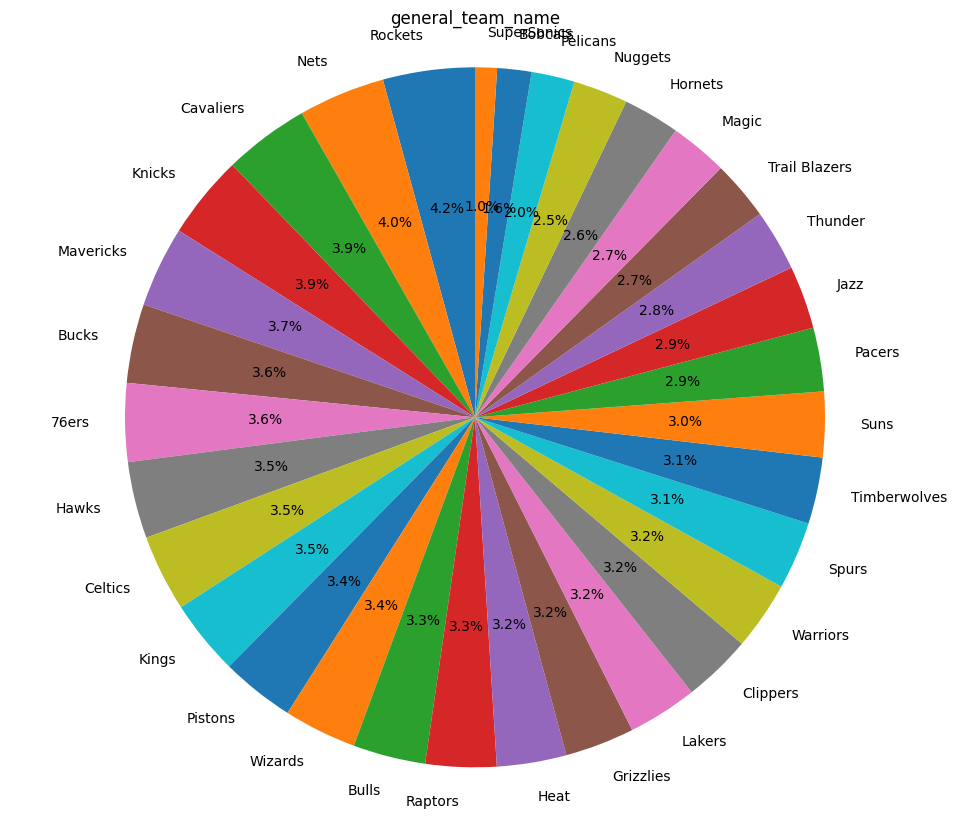

In [27]:
cat_analysis(df_work[['general_team_name']])

Esta columna no requiere transformaciones adicionales.

- Columna full_name

Esta columna informa del nombre del jugador, como en el caso de los equipos vamos a revisar que no haya valores nulos y si no los hay no requerirá de tratamiento posterior.

In [28]:
df_work['full_name'].isna().sum()

np.int64(0)

- Columna is_active

Esta columna informa de si el jugador está en activo o no. Ya la hemos tratado anteriormente pero vamos a revisar de nuevo que todo haya quedado correctamente lanzando el análisis para la columna categórica.

VARIABLE: is_active
 
Número de categorías: 2
 
Distribución de frecuencias
is_active
Inactive    2668
Active      1007
Name: count, dtype: int64
 
Porcentajes
is_active
Inactive    72.6
Active      27.4
Name: proportion, dtype: float64






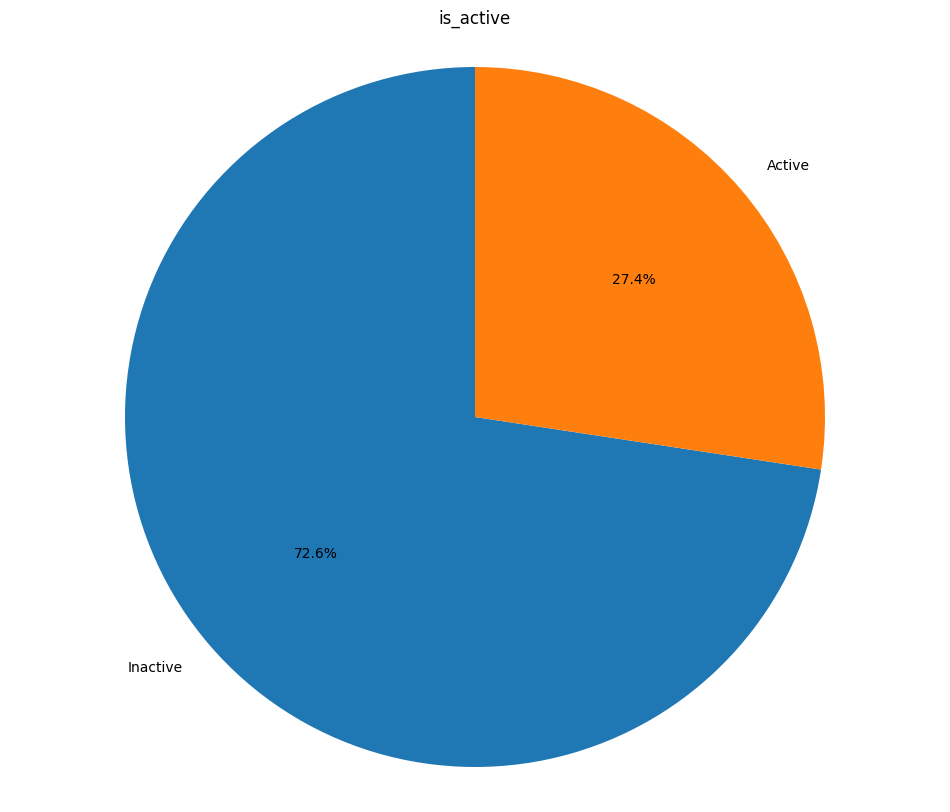

In [29]:
cat_analysis(df_work[['is_active']])

- Columna draft_city:

Esta columna nos informa de la ciudad en la que el jugador fue drafteado vamos a revisar que no contenga ningun valor extraño como si lo hacía la columna de equipos.

VARIABLE: draft_city
 
Número de categorías: 35
 
Distribución de frecuencias
draft_city
Undrafted                    874
Los Angeles                  152
Boston                       136
Philadelphia                 128
Sacramento                   126
Detroit                      120
Atlanta                      111
Phoenix                      107
Cleveland                    107
Chicago                      100
Utah                          97
Milwaukee                     97
Orlando                       94
Charlotte                     94
Indiana                       92
New York                      91
Minnesota                     90
Memphis                       89
Golden State                  87
Houston                       86
Denver                        85
Washington                    83
Portland                      80
Dallas                        70
Miami                         67
San Antonio                   66
Seattle                       61
New Jersey          

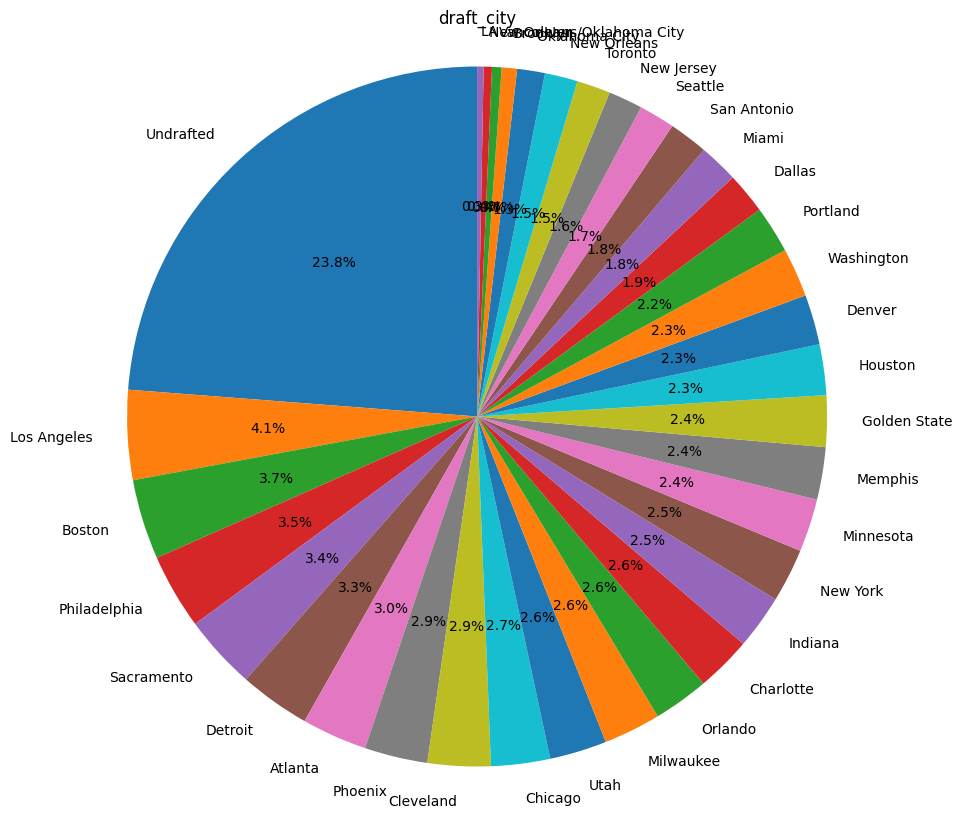

In [30]:
cat_analysis(df_work[['draft_city']])

Tras esto detectamos dos categorías que nos llaman la atención: 
- New Orleans/Oklahoma City: Este es como el caso encontrado en la columna de team solo que en este caso la solución no requerirá que borremos los datos ya que en el año de la mudanza de los equipos, los jugadores fueron drafteados en New Orleans. Por esto, sustituiremos los valores en dicha categoría por New Orleans. 

- LA: Volveremos a proceder como en el caso anterior.

In [31]:
#Sustituimos por New Orleans
df_work['draft_city'] = df_work['draft_city'].replace('New Orleans/Oklahoma City', 'New Orleans')

#Sustituimos LA
df_work['draft_city'] = df_work['draft_city'].replace('LA', 'Los Angeles')

#Obtenemos los valores unicos de la columna 
df_work['draft_city'].unique()

<StringArray>
[        'Miami',  'Golden State',       'Houston',       'Orlando',
       'Phoenix',  'Philadelphia',      'New York',     'Undrafted',
     'Cleveland',    'New Jersey',        'Boston',     'Vancouver',
   'Los Angeles',        'Dallas',       'Detroit',          'Utah',
       'Chicago',    'Sacramento',      'Portland',        'Denver',
    'Washington',     'Milwaukee',       'Seattle',       'Indiana',
     'Minnesota',       'Atlanta',     'Charlotte',       'Toronto',
       'Memphis',   'New Orleans',   'San Antonio', 'Oklahoma City',
      'Brooklyn']
Length: 33, dtype: str

- Columna draft_team_name

Esta columna nos muestra el nombre del equipo en el que el jugador fue drafteado. Vamos a revisar que no haya valores nulos ni extraños que debamos de corregir.

VARIABLE: draft_team_name
 
Número de categorías: 34
 
Distribución de frecuencias
draft_team_name
Undrafted        874
Celtics          136
76ers            128
Kings            126
Pistons          120
Hawks            111
Suns             107
Cavaliers        107
Grizzlies        105
Bulls            100
Jazz              97
Bucks             97
Magic             94
Hornets           93
Pacers            92
Knicks            91
Timberwolves      90
Warriors          87
Clippers          87
Rockets           86
Nuggets           85
Nets              84
Trail Blazers     80
Lakers            76
Wizards           74
Mavericks         70
Heat              67
Spurs             66
SuperSonics       61
Raptors           57
Bobcats           49
Thunder           47
Pelicans          22
Bullets            9
Name: count, dtype: int64
 
Porcentajes
draft_team_name
Undrafted        23.78
Celtics           3.70
76ers             3.48
Kings             3.43
Pistons           3.27
Hawks           

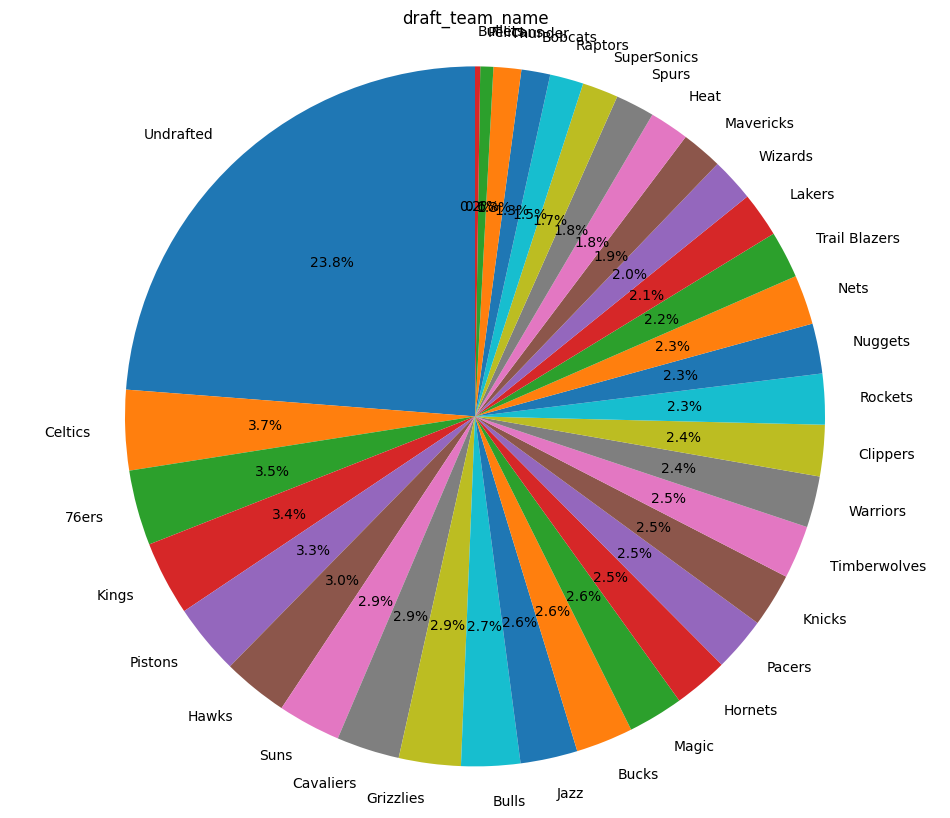

In [32]:
cat_analysis(df_work[['draft_team_name']])

En esta columna todo parece estar perfectamente y no requiere de mayores modificaciones.

- Columna organization_type:

Esta columna nos informa del tipo de organización de la que venía el jugador antes de ser drafteado. Como en el caso anterior vamos a revisar que no haya valores extraños ni nulos para confirmar que no requiera de transformaciones:

VARIABLE: organization_type
 
Número de categorías: 4
 
Distribución de frecuencias
organization_type
College/University    2368
Unknown                876
Other Team/Club        307
High School            124
Name: count, dtype: int64
 
Porcentajes
organization_type
College/University    64.44
Unknown               23.84
Other Team/Club        8.35
High School            3.37
Name: proportion, dtype: float64






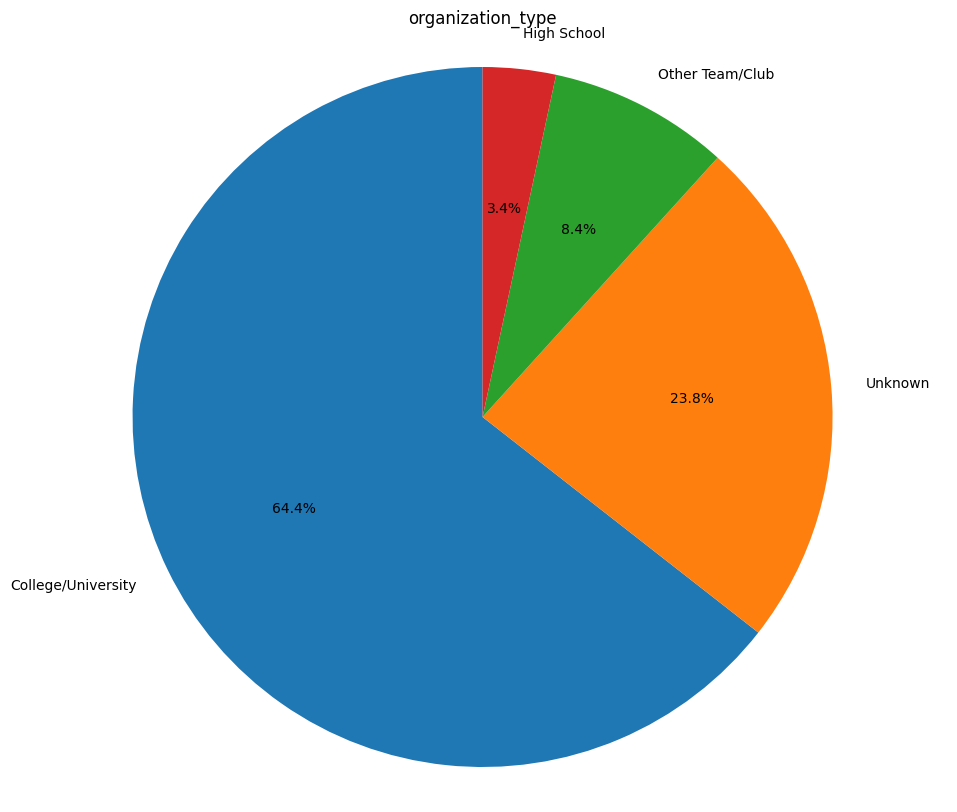

In [33]:
cat_analysis(df_work[['organization_type']])

Los datos parecen ser coherentes y la columna no requiere de mayores transformaciones ya que por mucho que el numero de desconocidos sea alto no es conveniente que extrapolemos el tipo de organización.

- Columna country

Esta columna informa de la nacionalidad del jugador, vamos a realizar el análisis de columnas categóricas para verificar que todo esté correctamente y de no detectar ningun caso extraño la columna no requiere mayores transformaciones.

VARIABLE: country
 
Número de categorías: 65
 
Distribución de frecuencias
country
USA          3032
France         66
Canada         56
Serbia         39
Australia      36
             ... 
Panama          1
Macedonia       1
Austria         1
Portugal        1
Colombia        1
Name: count, Length: 65, dtype: int64
 
Porcentajes
country
USA          82.50
France        1.80
Canada        1.52
Serbia        1.06
Australia     0.98
             ...  
Panama        0.03
Macedonia     0.03
Austria       0.03
Portugal      0.03
Colombia      0.03
Name: proportion, Length: 65, dtype: float64






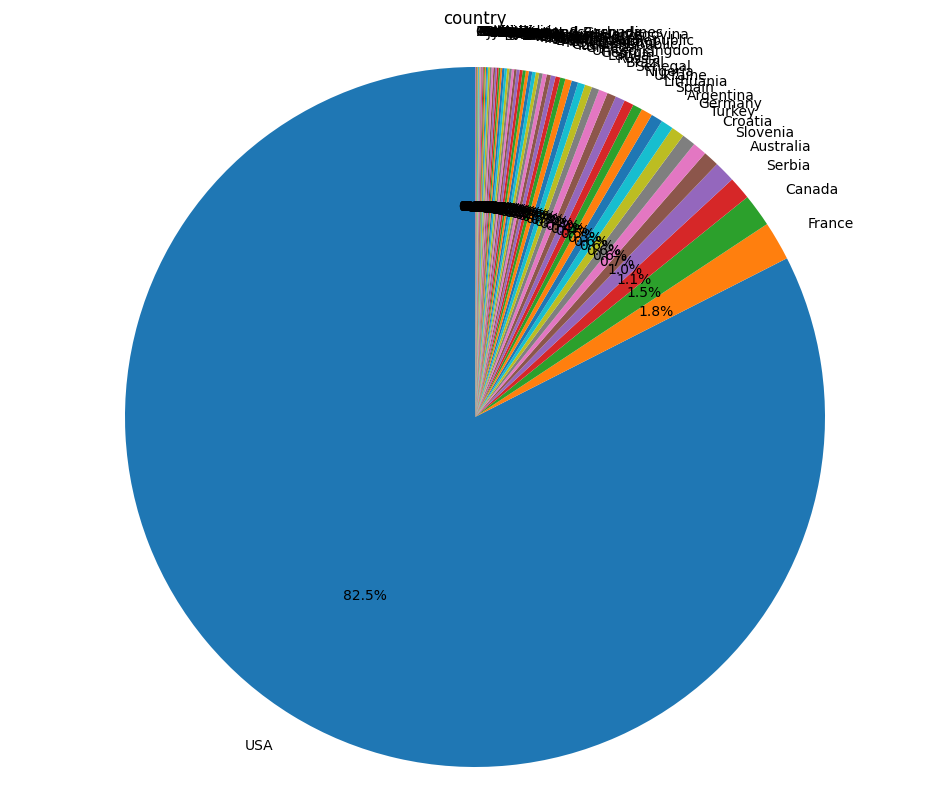

In [34]:
cat_analysis(df_work[['country']])

Esta columna presenta demasiadas categorías por lo que vamos simplificarla creando hubs con los países aunque dejaremos a USA como un hub con un único país debido a la alta incidencia que tiene en el dataset.

In [35]:
#Obtenemos todos los valores únicos de la columna
df_work['country'].unique()

<StringArray>
[                     'USA',                  'Croatia',
                'Australia',                  'Ukraine',
                     'Cuba',                  'Romania',
                  'Nigeria',                   'France',
                'Argentina',                    'China',
   'Bosnia and Herzegovina',                   'Canada',
                    'Haiti',                   'Serbia',
                    'Congo',                  'Senegal',
                   'Mexico',                'Venezuela',
                 'Scotland',                   'Greece',
                   'Poland',                'Lithuania',
                   'Brazil',           'Czech Republic',
                   'Russia',                   'Turkey',
              'New Zealand',                  'Georgia',
                   'Latvia',              'Puerto Rico',
       'Dominican Republic',              'South Sudan',
                 'Slovenia',                    'Spain',
           'Unite

In [36]:
#Creamos un diccionario en el que incluimos los hubs creados: 
hubs = {
    # USA - hub propio
    'USA'                      : 'USA',

    # Europa Occidental
    'France'                   : 'Western Europe',
    'Spain'                    : 'Western Europe',
    'Germany'                  : 'Western Europe',
    'Italy'                    : 'Western Europe',
    'Netherlands'              : 'Western Europe',
    'Belgium'                  : 'Western Europe',
    'Portugal'                 : 'Western Europe',
    'Austria'                  : 'Western Europe',
    'Ireland'                  : 'Western Europe',
    'Scotland'                 : 'Western Europe',
    'United Kingdom'           : 'Western Europe',
    'Finland'                  : 'Western Europe',

    # Europa del Este
    'Croatia'                  : 'Eastern Europe',
    'Ukraine'                  : 'Eastern Europe',
    'Romania'                  : 'Eastern Europe',
    'Serbia'                   : 'Eastern Europe',
    'Bosnia and Herzegovina'   : 'Eastern Europe',
    'Slovenia'                 : 'Eastern Europe',
    'Poland'                   : 'Eastern Europe',
    'Czech Republic'           : 'Eastern Europe',
    'Russia'                   : 'Eastern Europe',
    'Latvia'                   : 'Eastern Europe',
    'Lithuania'                : 'Eastern Europe',
    'Georgia'                  : 'Eastern Europe',
    'Montenegro'               : 'Eastern Europe',
    'Macedonia'                : 'Eastern Europe',
    'Greece'                   : 'Eastern Europe',
    'Turkey'                   : 'Eastern Europe',

    # América Latina
    'Cuba'                     : 'Latin America',
    'Argentina'                : 'Latin America',
    'Haiti'                    : 'Latin America',
    'Brazil'                   : 'Latin America',
    'Dominican Republic'       : 'Latin America',
    'Venezuela'                : 'Latin America',
    'Colombia'                 : 'Latin America',
    'Panama'                   : 'Latin America',

    # Caribe
    'Puerto Rico'              : 'Caribbean',
    'US Virgin Islands'        : 'Caribbean',
    'Bahamas'                  : 'Caribbean',
    'Jamaica'                  : 'Caribbean',
    'Saint Lucia'              : 'Caribbean',
    'Antigua and Barbuda'      : 'Caribbean',
    'St. Vincent & Grenadines' : 'Caribbean',

    # África
    'Nigeria'                  : 'Africa',
    'Congo'                    : 'Africa',
    'Senegal'                  : 'Africa',
    'Cameroon'                 : 'Africa',
    'Gabon'                    : 'Africa',
    'Mali'                     : 'Africa',
    'Egypt'                    : 'Africa',
    'Sudan'                    : 'Africa',
    'South Sudan'              : 'Africa',
    'Angola'                   : 'Africa',
    'Guinea'                   : 'Africa',
    'Tanzania'                 : 'Africa',
    'DRC'                      : 'Africa',

    # Oceanía
    'Australia'                : 'Oceania',
    'New Zealand'              : 'Oceania',

    # Asia
    'China'                    : 'Asia',
    'Iran'                     : 'Asia',
    'Israel'                   : 'Asia',
    'Japan'                    : 'Asia',

    # América del Norte
    'Canada'                   : 'North America',
    'Mexico'                   : 'North America',
}

#Aplicamos los hubs a una nueva columna 
df_work['hub'] = df_work['country'].map(hubs)
print ("Columna creada")

Columna creada


Por último, lanzamos el análisis sobre esta última columna para ver que nos es de utilidad y podemos obtener insights más valiosos:

VARIABLE: hub
 
Número de categorías: 9
 
Distribución de frecuencias
hub
USA               3032
Eastern Europe     228
Western Europe     145
Africa              73
North America       60
Latin America       57
Oceania             44
Caribbean           25
Asia                11
Name: count, dtype: int64
 
Porcentajes
hub
USA               82.50
Eastern Europe     6.20
Western Europe     3.95
Africa             1.99
North America      1.63
Latin America      1.55
Oceania            1.20
Caribbean          0.68
Asia               0.30
Name: proportion, dtype: float64






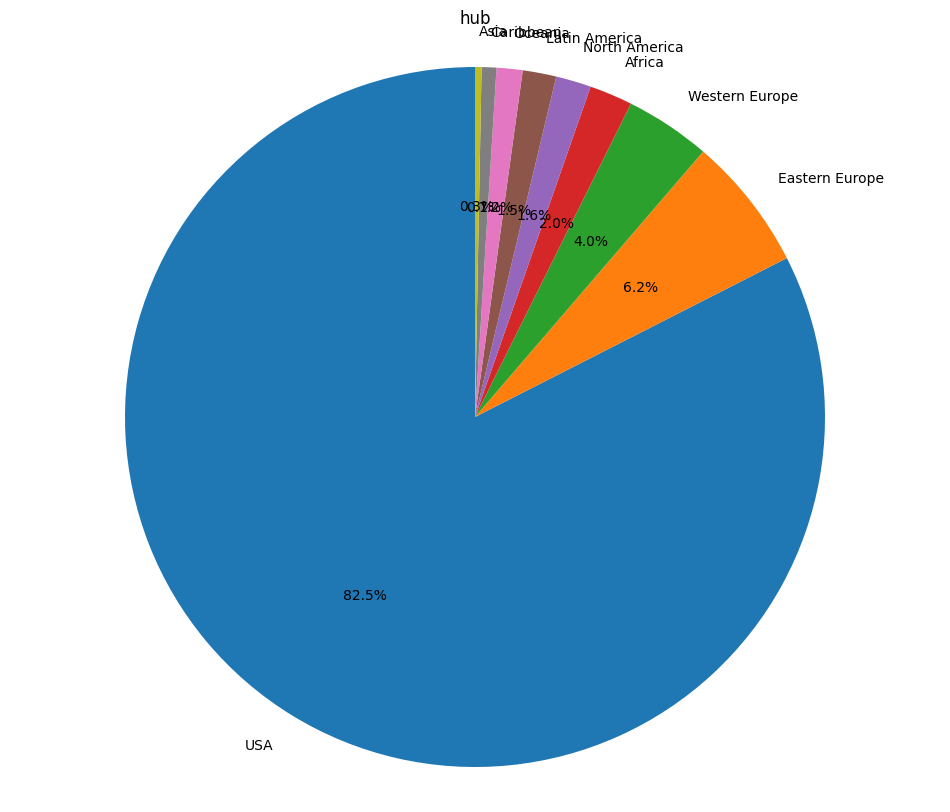

In [37]:
cat_analysis(df_work[['hub']])

Comprobamos que no queden nulos en la columna tras los cambios:

In [38]:
df_work['hub'].isna().sum()

np.int64(0)

Eliminamos la columna de country del dataframe ya que utilizaremos la de hubs:

In [39]:
df_work = df_work.drop(columns= ['country'])

Con esto la columna es más interpretable para el estudio y podemos proseguir con la transformación.

- Columna position

Esta columna de la posición en la que juega el jugador, vamos a revisar los valores que la forman y que no incluya nulos. Si todo está correcto procederemos a la limpieza de la siguiente columna ya que está no requiere de cambios mayores.

VARIABLE: position
 
Número de categorías: 7
 
Distribución de frecuencias
position
Guard             1345
Forward           1084
Center             438
Guard-Forward      290
Forward-Center     251
Center-Forward     155
Forward-Guard      112
Name: count, dtype: int64
 
Porcentajes
position
Guard             36.60
Forward           29.50
Center            11.92
Guard-Forward      7.89
Forward-Center     6.83
Center-Forward     4.22
Forward-Guard      3.05
Name: proportion, dtype: float64






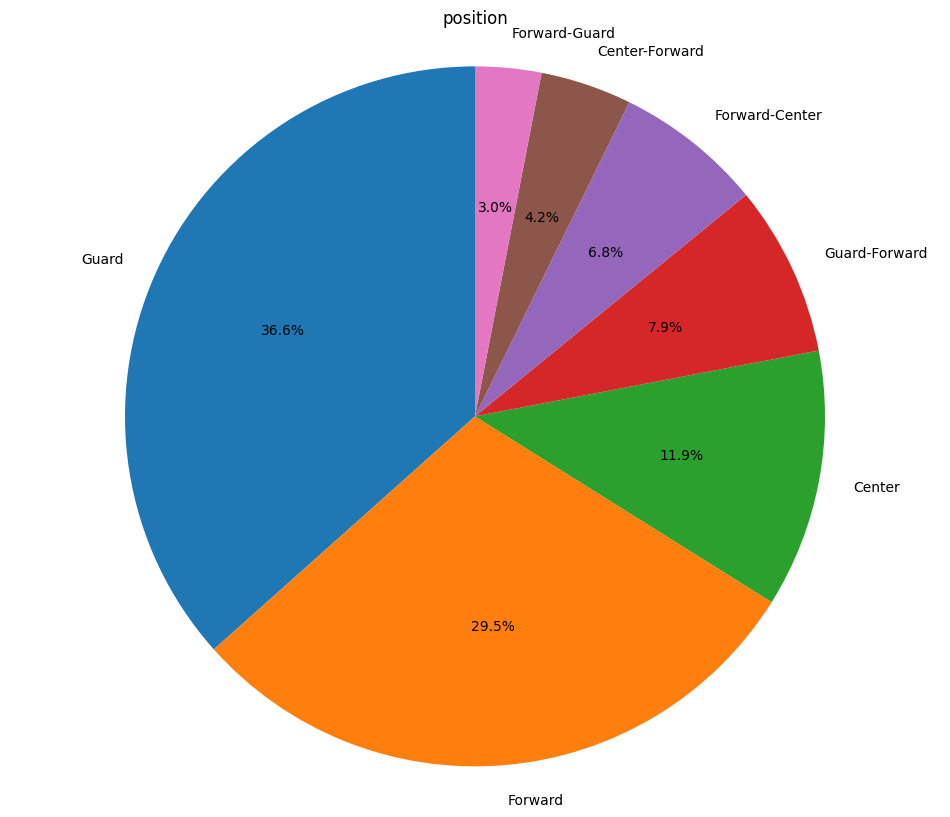

In [40]:
cat_analysis(df_work[['position']])

- Columna g-league

Esta columna informa de si el jugador ha pasado por la liga de desarrollo de la nba. Como en el caso anterior realizaremos el análisis de valores únicos y nulos y de no encontrar otros errores pasaremos a la transformación de la siguiente columna:

VARIABLE: g-league
 
Número de categorías: 2
 
Distribución de frecuencias
g-league
Y    1915
N    1760
Name: count, dtype: int64
 
Porcentajes
g-league
Y    52.11
N    47.89
Name: proportion, dtype: float64






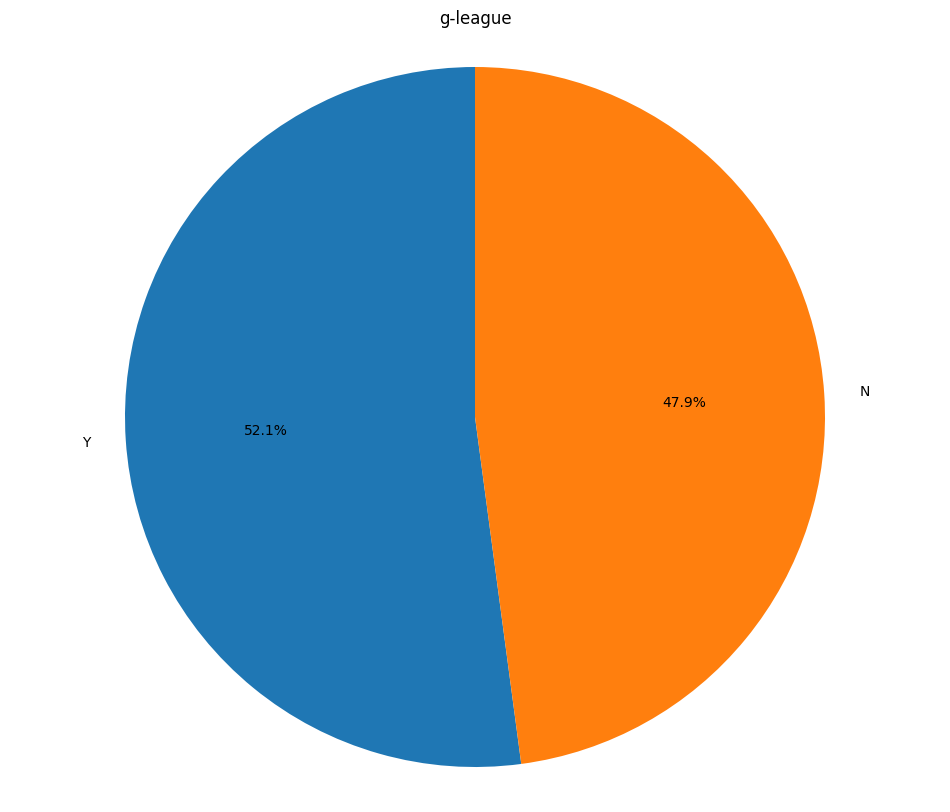

In [41]:
cat_analysis(df_work[['g-league']])

En este caso, vamos a sustituir los valores de las columnas de Y a Yes y de N a No con la función map:

In [42]:
df_work ['g-league'] = df_work['g-league'].map({'Y' : 'Yes', 'N' : 'No'})
print ("Valores sustituidos")

Valores sustituidos


Ahora comprobamos que todo se haya sustituido correctamente utilizando la función value_counts:

In [43]:
df_work[['g-league']].value_counts()

g-league
Yes         1915
No          1760
Name: count, dtype: int64

- Columna nba:

Esta columna informa de si el jugador ha pasado por la nba o no. Como en el caso anterior realizaremos el análisis de valores únicos y nulos y de no encontrar otros errores pasaremos a la transformación de la siguiente columna:

VARIABLE: nba
 
Número de categorías: 2
 
Distribución de frecuencias
nba
Y    3661
N      14
Name: count, dtype: int64
 
Porcentajes
nba
Y    99.62
N     0.38
Name: proportion, dtype: float64






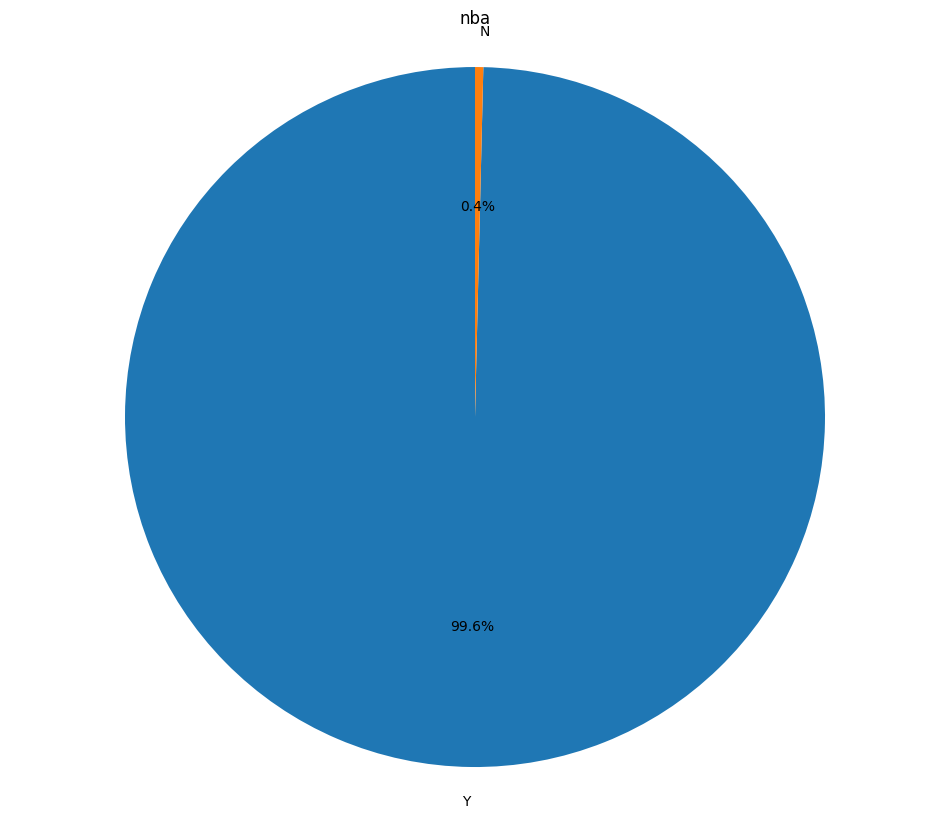

In [44]:
cat_analysis(df_work[['nba']])

En este caso al seguir encontrando valores de jugadores que no han jugado en la NBA y nuestro estudio está solo centrado en jugadores que han jugado en la nba, vamos a analizar por que esos jugadores no han jugado y decidimos a posteriori que haremos con ellos:

In [45]:
print(df_work[df_work['nba'] == 'N'][['full_name', 'general_team_name']])

             full_name general_team_name
745       Herbert Hill             76ers
1194   Curtis Jerrells             Spurs
1210       Brian Butch           Nuggets
1213      Tony Gaffney           Celtics
1425      Robert Vaden           Thunder
1428      Magnum Rolle             Hawks
1555    Diamon Simpson           Rockets
2687     Tarik Phillip           Wizards
2849      Kenny Wooten            Knicks
3146    Caleb Homesley           Wizards
3441        DJ Stewart             Spurs
3464  Collin Gillespie           Nuggets
3477     Chet Holmgren           Thunder
3647      Justin Lewis             Bulls


En este caso, son jugadores que fueron drafteados/fichados pero que tras una lesión no jugaron en la nba salvo algunos casos (e.g Chet Holmgren). Visto que estos casos pueden afectar a nuestro estudio alterando mínimamente algunas magnitudes estadísticas vamos a eliminar las filas cuyos jugadores no llegaron a debutar.

In [46]:
#Revisamos los registros antes de eliminar 
print(df_work.shape)

#Eliminamos los registros del dataset
df_work = df_work[df_work['nba'] != 'N'].reset_index(drop=True)
print ("Registros eliminados")

#Revisamos los registros después de eliminar
print (df_work.shape)

(3675, 20)
Registros eliminados
(3661, 20)


Tras esta eliminación, vamos a eliminar también la columna ya que ahora carece de sentido tenerla puesto que todos sus registros son jugadores que han jugado en la NBA. 

In [47]:
df_work = df_work.drop(columns= ['nba'])

print("Columna eliminada")

Columna eliminada


- Columna greatest_75_flag

Esta columna nos muestra si el jugador fue seleccionado entre los 75 mejores jugadores de la historia de la NBA. Como en casos anteriores vamos a revisar que no haya nulos ni valores extraños y de no haberlos procederemos a la siguiente fase del estudio.

VARIABLE: greatest_75_flag
 
Número de categorías: 2
 
Distribución de frecuencias
greatest_75_flag
N    3605
Y      56
Name: count, dtype: int64
 
Porcentajes
greatest_75_flag
N    98.47
Y     1.53
Name: proportion, dtype: float64






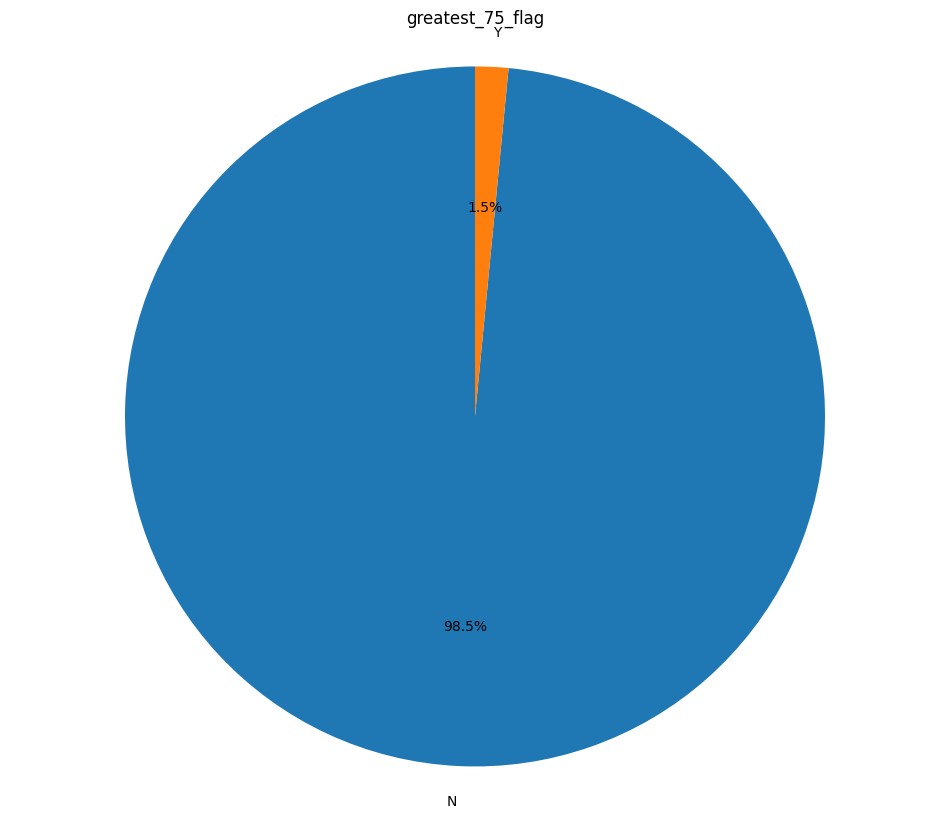

In [48]:
cat_analysis(df_work[['greatest_75_flag']])

Nos llama la atención que solo hay 56 registros de jugadores entre los mejores 75. Esto nos indica algo que ya sabíamos y es, que no todos los jugadores de la historia están siendo tenidos en cuenta en este estudio pero si una gran mayoría que nos servirá para cubrir el objetivo del estudio. 

La única transformación que vamos a realizar es la de cambiar los nombres de las columnas como en casos anteriores por yes y no, asi que procedemos a realizar dicho cambio. 

In [49]:
df_work ['greatest_75_flag'] = df_work['greatest_75_flag'].map({'Y' : 'Yes', 'N' : 'No'})
print ("Valores sustituidos")

Valores sustituidos


In [50]:
df_work ['greatest_75_flag'].value_counts()

greatest_75_flag
No     3605
Yes      56
Name: count, dtype: int64

Por último, vamos a añadir una nueva columna a nuestro dataset indicando la cantidad de equipos en la que ha jugado un jugador para ver como esto afecta a la longevidad.

In [51]:
#Agrupamos la lista de los jugadores con groupby y contamos los valores unicos en la columna general team con nunique
teams_x_player = df_work.groupby('id')['general_team'].nunique()

#Mapeamos el resultado a cada jugador con map 
df_work['num_equipos'] = df_work['id'].map(teams_x_player)

#Revisamos la ejecución
print(df_work[['id', 'full_name', 'general_team', 'num_equipos']])

           id            full_name  general_team  num_equipos
0         120         Steven Smith    1610612737            1
1          32      Clifford Rozier    1610612753            1
2         440            Zan Tabak    1610612761            1
3         914      Stanley Roberts    1610612746            1
4         291          Ed Pinckney    1610612748            1
...       ...                  ...           ...          ...
3656   202324       Derrick Favors    1610612745            5
3657  1627737      Marquese Chriss    1610612760            6
3658   203504           Trey Burke    1610612760            6
3659  1626161  Willie Cauley-Stein    1610612745            4
3660  1630564         RaiQuan Gray    1610612751            1

[3661 rows x 4 columns]


Con esto, podemos dar por concluida la fase de transformación y podemos proceder a realizar el estudio por lo que vamos a exportar el dataset con las transformaciones.

In [52]:
df_work.to_csv("Dataframe_EDA.csv", index= False)
print("Dataframe exportado")

Dataframe exportado
